chatgpt_batch_concise: Number of equivalent samples: 3176 out of 3400
chatgpt_batch_concise: Number of filtered samples: 198 out of 3400
198 198 198 198
chatgpt_batch_verbose: Number of equivalent samples: 3192 out of 3400
chatgpt_batch_verbose: Number of filtered samples: 199 out of 3400
199 199 199 199
chatgpt_batch_rephrase: Number of equivalent samples: 3231 out of 3400
chatgpt_batch_rephrase: Number of filtered samples: 198 out of 3400
198 198 198 198


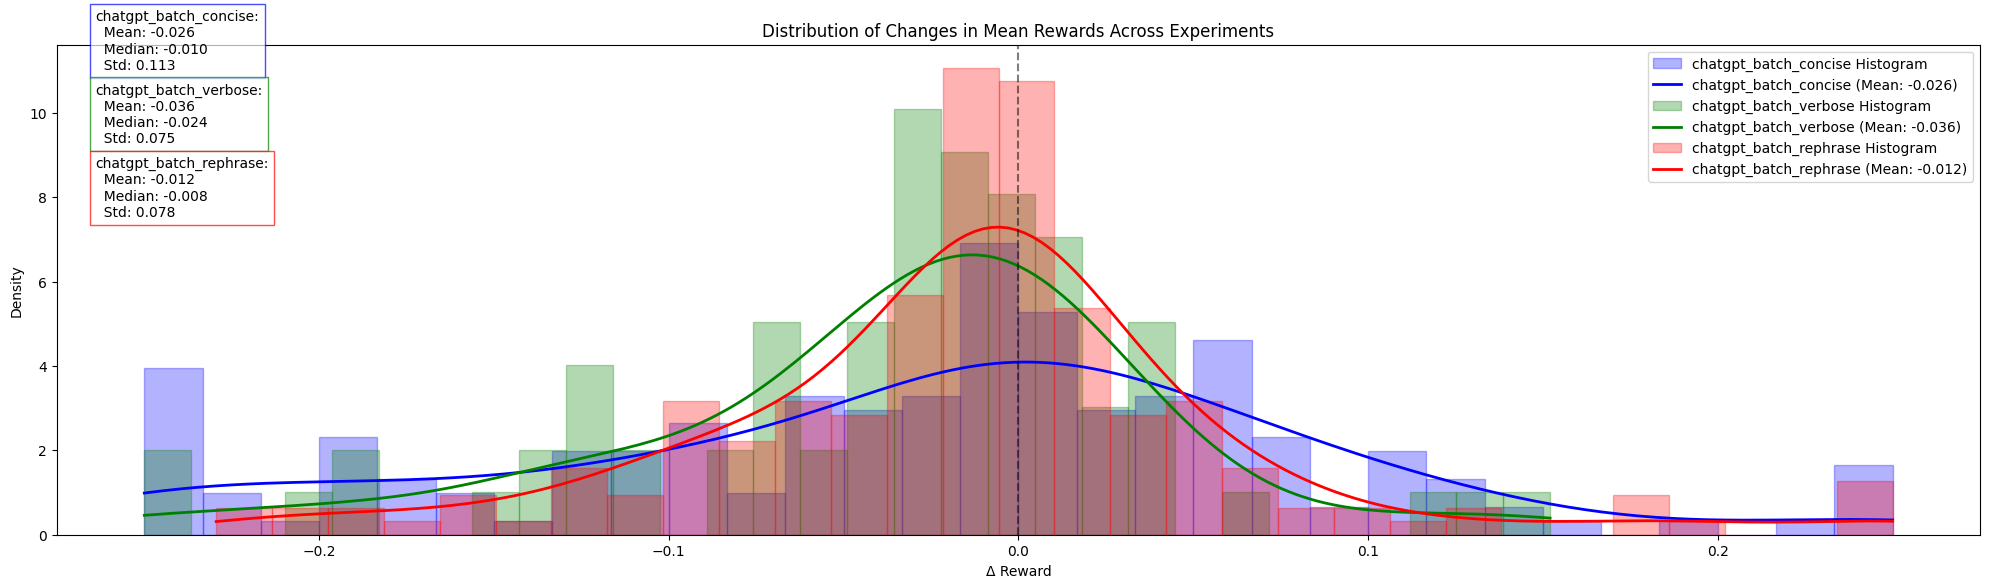

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# List of experiments to compare
experiment_names = ["chatgpt_batch_concise", "chatgpt_batch_verbose", "chatgpt_batch_rephrase"]
colors = ['blue', 'green', 'red']  # Different color for each experiment

plt.figure(figsize=(20, 6))

# Process each experiment
for i, experiment_name in enumerate(experiment_names):
    try:
        df_sample = pd.read_parquet(f"{experiment_name}/attack.parquet")
        # Filter data
        df_filtered = df_sample[df_sample["equivalence"] == True]
        print(f"{experiment_name}: Number of equivalent samples: {len(df_filtered)} out of {len(df_sample)}")
        df_filtered = df_filtered[df_filtered.apply(lambda row: len(row["aug_steps"]) == len(row["steps"]), axis=1)]
        df_filtered = df_filtered[df_filtered["aug_steps"].apply(lambda x: len(x) > 0)]
        df_filtered = df_filtered[df_filtered["steps"].apply(lambda x: len(x) > 0)]
        # df_filtered = df_filtered[df_filtered["label"] == -1]
        df_filtered = df_filtered[df_filtered['final_answer_correct']==True]
        df_filtered = df_filtered[df_filtered["split"] == "gsm8k"]
        # df_filtered = df_filtered[df_filtered["generator"].str.contains("qwen", case=False)]
        
        print(f"{experiment_name}: Number of filtered samples: {len(df_filtered)} out of {len(df_sample)}")
        
        # Calculate mean rewards for Skywork model
        # Collect all rewards into lists of lists
        # Calculate mean rewards for each sample
        # original_rewards_mean_skywork = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].apply(lambda x: x[-1]).tolist()
        # augmented_rewards_mean_skywork = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"].apply(lambda x: x[-1]).tolist()
        original_rewards_mean_skywork = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].tolist()
        augmented_rewards_mean_skywork = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"].tolist()

        # Calculate step lengths for original and augmented steps
        original_step_lengths = []
        augmented_step_lengths = []
        
        for idx, row in df_filtered.iterrows():
            # Get original steps and their lengths
            orig_steps = row["steps"]
            orig_lengths = [len(step) for step in orig_steps]
            original_step_lengths.append(orig_lengths)
            
            # Get augmented steps and their lengths
            aug_steps = row["aug_steps"]
            aug_lengths = [len(step) for step in aug_steps]
            augmented_step_lengths.append(aug_lengths)
        
        # Add step lengths to the dataframe
        df_filtered["original_step_lengths"] = original_step_lengths
        df_filtered["augmented_step_lengths"] = augmented_step_lengths

        original_step_lengths_flat = [length for sublist in original_step_lengths for length in sublist[:1]]
        augmented_step_lengths_flat = [length for sublist in augmented_step_lengths for length in sublist[:1]]
        original_rewards_mean_skywork = [reward for sublist in original_rewards_mean_skywork for reward in sublist[:1]]
        augmented_rewards_mean_skywork = [reward for sublist in augmented_rewards_mean_skywork for reward in sublist[:1]]

        print(len(original_step_lengths_flat), len(augmented_step_lengths_flat), len(original_rewards_mean_skywork), len(augmented_rewards_mean_skywork))
        filtered_original_rewards_skywork = []
        filtered_augmented_rewards_skywork = []
        for j in range(len(original_step_lengths_flat)):
            if 'concise' in experiment_name:
                if augmented_step_lengths_flat[j] < original_step_lengths_flat[j]*0.8:
                    filtered_original_rewards_skywork.append(original_rewards_mean_skywork[j])
                    filtered_augmented_rewards_skywork.append(augmented_rewards_mean_skywork[j])
            elif 'verbose' in experiment_name:
                if original_step_lengths_flat[j] < augmented_step_lengths_flat[j]*0.8:
                    filtered_original_rewards_skywork.append(original_rewards_mean_skywork[j])
                    filtered_augmented_rewards_skywork.append(augmented_rewards_mean_skywork[j])
            elif 'rephrase' in experiment_name:
                filtered_original_rewards_skywork.append(original_rewards_mean_skywork[j])
                filtered_augmented_rewards_skywork.append(augmented_rewards_mean_skywork[j])

        original_rewards_mean_skywork = filtered_original_rewards_skywork
        augmented_rewards_mean_skywork = filtered_augmented_rewards_skywork

                
        # Calculate deltas
        mean_reward_deltas_skywork = np.array(augmented_rewards_mean_skywork) - np.array(original_rewards_mean_skywork)
        mean_reward_deltas_skywork = np.clip(mean_reward_deltas_skywork, -0.25, 0.25)

        
        # Plot histogram with transparency
        plt.hist(mean_reward_deltas_skywork, bins=30, density=True, alpha=0.3, 
                 edgecolor=colors[i], color=colors[i], label=f'{experiment_name} Histogram')
        
        # Add KDE curve
        kde = stats.gaussian_kde(mean_reward_deltas_skywork)
        x_range = np.linspace(mean_reward_deltas_skywork.min(), mean_reward_deltas_skywork.max(), 200)
        plt.plot(x_range, kde(x_range), color=colors[i], lw=2, 
                 label=f'{experiment_name} (Mean: {mean_reward_deltas_skywork.mean():.3f})')
        
        # Add statistics to text box
        plt.text(0.02, 0.95 - i*0.15,
                f'{experiment_name}:\n  Mean: {mean_reward_deltas_skywork.mean():.3f}\n  Median: {np.median(mean_reward_deltas_skywork):.3f}\n  Std: {mean_reward_deltas_skywork.std():.3f}',
                transform=plt.gca().transAxes,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor=colors[i]))
    
    except Exception as e:
        print(f"Error processing {experiment_name}: {e}")

plt.title('Distribution of Changes in Mean Rewards Across Experiments')
plt.xlabel('Δ Reward')
plt.ylabel('Density')
plt.legend()
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Joint KDE Plot

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import gaussian_kde

def joint_kde_plot(x, y, n_levels=15, bins=30, title=None):
    """
    x, y          : 1‑D numpy arrays of equal length
    n_levels      : number of contour levels for the 2‑D KDE
    bins          : histogram bins for the marginals
    """
    # ── layout: top = x‑marginal, right = y‑marginal ──────────────────────
    fig = plt.figure(figsize=(5, 5))
    gs  = gridspec.GridSpec(2, 2,
                            width_ratios=[4, 1],
                            height_ratios=[1, 4],
                            wspace=0.05, hspace=0.05)

    ax_top   = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    # ── 2‑D KDE ───────────────────────────────────────────────────────────
    xx = np.linspace(-0.2, 0.2, 200)
    yy = np.linspace(min(y), max(y), 200)
    XX, YY = np.meshgrid(xx, yy)
    kde     = gaussian_kde([x, y])
    ZZ      = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)

    ax_joint.contourf(XX, YY, ZZ, levels=n_levels)
    ax_joint.set_xlabel("delta reward")
    ax_joint.set_ylabel("delta cumulative step length (log)")
    ax_joint.set_xlim(-0.2, 0.2)

    ax_top.hist(x, bins=bins, density=True, alpha=0.6)
    ax_right.hist(y, bins=bins, density=True,
                  orientation="horizontal", alpha=0.6)

    ax_top.set_xticks([]) 
    ax_top.set_yticks([])

    ax_right.set_xticks([]) 
    ax_right.set_yticks([])

    if title:
        fig.suptitle(title)
    
    plt.show()

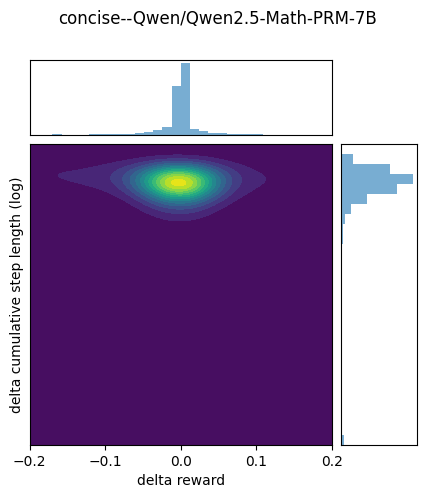

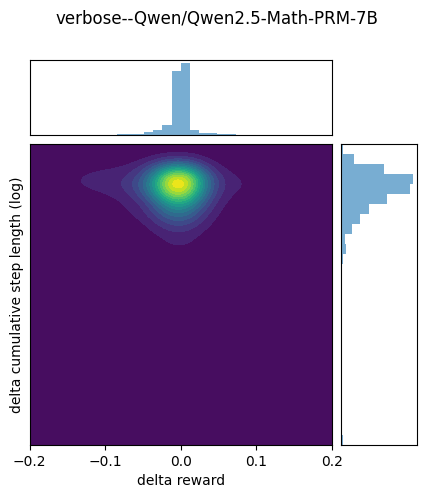

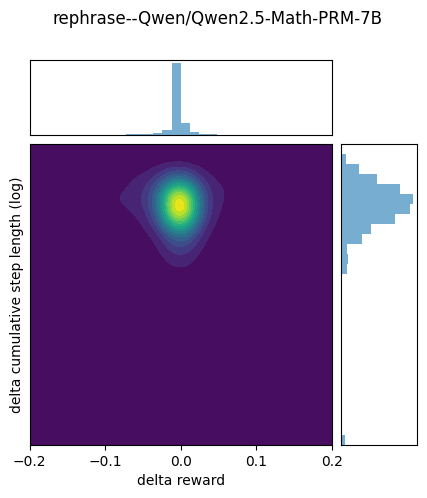

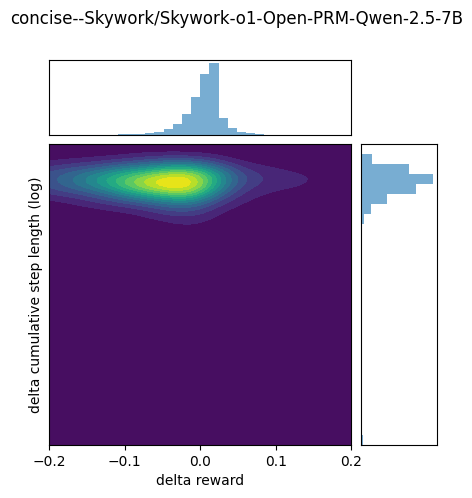

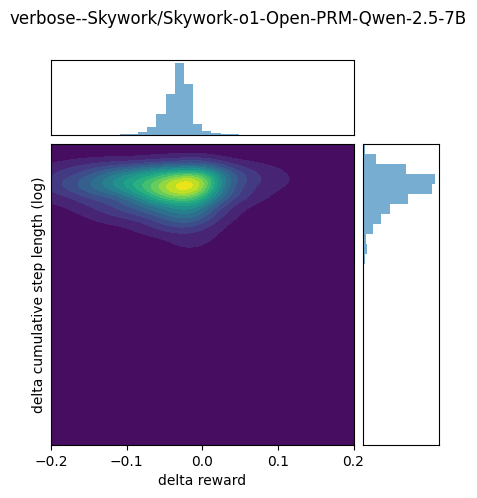

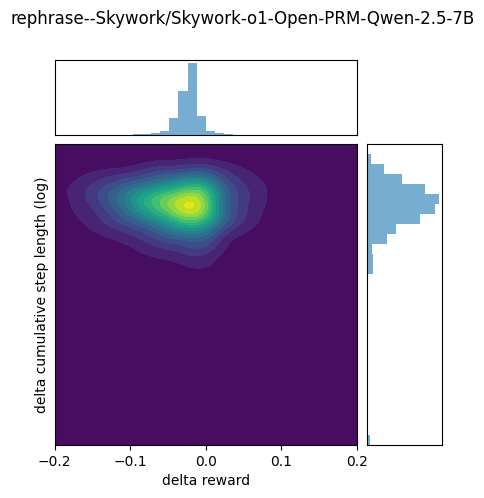

In [17]:
EXPERIMENT_NAMES = ["chatgpt_batch_concise", "chatgpt_batch_verbose", "chatgpt_batch_rephrase"]
FINAL_ANSWER_CORRECT = None # True or False or None
SPLIT = "olympiadbench" # "gsm8k" or "math" or "olympiadbench" or "omnimath" or "all"
MODELS = ["Qwen/Qwen2.5-Math-PRM-7B", "Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B"]
flatten_to_numpy = lambda _list: np.array([item for sublist in _list for item in sublist])

for model in MODELS:
    for exp in EXPERIMENT_NAMES:
        df_sample = pd.read_parquet(f"{exp}/attack.parquet")

        # Filter data
        ## Equivalence and step length checks
        df_filtered = df_sample[df_sample["equivalence"] == True]
        df_filtered = df_filtered[df_filtered.apply(lambda row: len(row[model.split("/")[-1]]) == len(row[model+"--aug_rewards"]), axis=1)]
        ## Augmented steps and original steps are non-empty
        df_filtered = df_filtered[df_filtered["aug_steps"].apply(lambda x: len(x) > 0)]
        df_filtered = df_filtered[df_filtered["steps"].apply(lambda x: len(x) > 0)]
        ## Final answer is correct
        if FINAL_ANSWER_CORRECT is not None:
            df_filtered = df_filtered[df_filtered['final_answer_correct']==FINAL_ANSWER_CORRECT]

        ## Decide splitchatgpt_batch_concise
        if SPLIT != "all":
            df_filtered = df_filtered[df_filtered["split"] == SPLIT]

        ## Filtering done, now calculating deltas
        original_rewards_skywork = df_filtered[model.split("/")[-1]].tolist()
        augmented_rewards_skywork = df_filtered[model+"--aug_rewards"].tolist()
        ## Calculate deltas
        reward_deltas_skywork = flatten_to_numpy(augmented_rewards_skywork) - flatten_to_numpy(original_rewards_skywork)

        ## Calculate log step lengths
        original_step_cumulative_lengths = [np.cumsum([len(step) for step in steps]) for steps in df_filtered["steps"].tolist()]
        augmented_step_cumulative_lengths = [np.cumsum([len(step) for step in steps]) for steps in df_filtered["aug_steps"].tolist()]
        ## Calculate deltas
        step_deltas_skywork = np.log(np.abs(flatten_to_numpy(augmented_step_cumulative_lengths) - flatten_to_numpy(original_step_cumulative_lengths)) + 1e-5)

        ## Plot joint kde plot
        joint_kde_plot(reward_deltas_skywork, step_deltas_skywork, title=exp.split("_")[-1] + "--" + model)
